# 🏠 Semana 07: California Housing - Regresión con Boosting
## Dataset: California Housing (Precios de viviendas)

**Objetivo:** Predecir el precio medio de una vivienda en California basándose en características del distrito.

**Modelos a competir:**
- XGBoost Regressor (reg:squarederror)
- LightGBM Regressor (regression)
- CatBoost Regressor (RMSE)

**Métricas de evaluación:** RMSE, MAE, R², Tiempo de entrenamiento

**Contexto de negocio:** Una inmobiliaria quiere estimar el valor de propiedades en diferentes zonas para fijar precios competitivos.

---

### ¿Qué es?
Dataset que contiene información sobre **20,640 bloques de viviendas** en California, basado en el censo de 1990. Características por distrito:
- Ingreso medio
- Edad media de las casas
- Número promedio de habitaciones
- Número promedio de dormitorios
- Población del bloque
- Ocupación promedio
- Latitud y longitud

### ¿Qué problema resuelve?
Predecir el **precio medio de una vivienda** en un distrito (valor continuo en cientos de miles de dólares).

### El Reto
**Escalar a Big Data** - Comparar los 3 grandes del **Gradient Boosting** en regresión:
- **XGBoost**: El más maduro, buena precisión
- **LightGBM**: El más rápido, menor memoria
- **CatBoost**: Maneja categóricas nativamente

### Contexto de negocio
Una inmobiliaria quiere estimar el valor de propiedades en diferentes zonas para fijar precios competitivos.

## 1. Configuración Inicial

Importamos las librerías necesarias y configuramos la semilla para reproducibilidad.

In [1]:
# ======================================================
# SEMANA 07: CALIFORNIA HOUSING - REGRESIÓN CON BOOSTING
# ======================================================

# Instalar librerías necesarias
!pip install scikit-learn pandas numpy matplotlib seaborn xgboost lightgbm catboost -q

# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modelos de boosting para regresión
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Semilla para reproducibilidad
np.random.seed(42)

print("✅ Librerías importadas correctamente")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.6 MB/s eta 0:00:00
✅ Librerías importadas correctamente


## 2. Carga y Exploración de Datos

Cargamos el dataset California Housing directamente desde scikit-learn.

In [2]:
# Cargar dataset California Housing
print("="*60)
print("📊 CARGANDO DATASET CALIFORNIA HOUSING")
print("="*60)

housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

print(f"\n✅ Dataset cargado exitosamente")
print(f"📊 SHAPE: {X.shape[0]:,} muestras × {X.shape[1]} características")
print(f"🎯 Target: Precio medio de vivienda (en cientos de miles de dólares)")
print(f"📋 Características: {list(X.columns)}")

# Mostrar primeras filas
print("\n📋 Primeras 5 filas del dataset:")
display(X.head())

# Estadísticas descriptivas
print("\n📊 Estadísticas descriptivas:")
display(X.describe())

📊 CARGANDO DATASET CALIFORNIA HOUSING

✅ Dataset cargado exitosamente
📊 SHAPE: 20,640 muestras × 8 características
🎯 Target: Precio medio de vivienda (en cientos de miles de dólares)
📋 Características: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

📋 Primeras 5 filas del dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



📊 Estadísticas descriptivas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


📈 ANÁLISIS EXPLORATORIO DEL TARGET


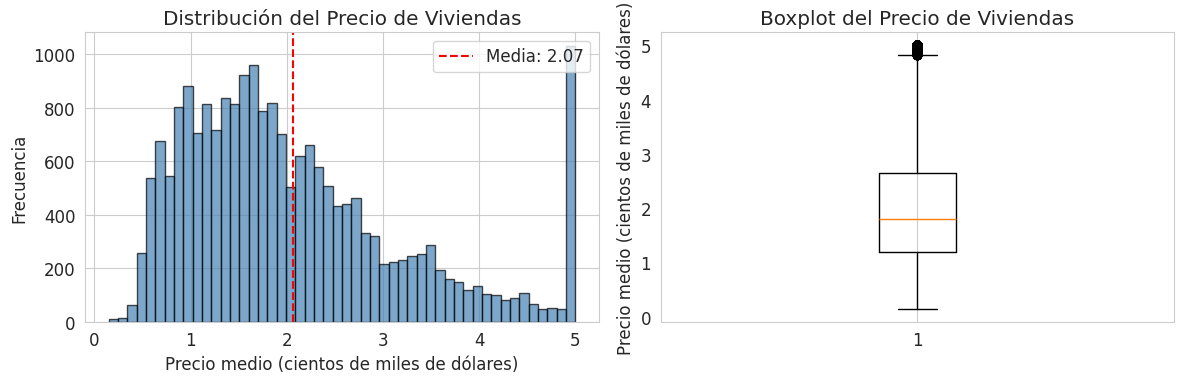


📊 Estadísticas del target:
   • Media: 2.0686
   • Mediana: 1.7970
   • Desviación estándar: 1.1540
   • Mínimo: 0.1500
   • Máximo: 5.0000


In [3]:
# Análisis exploratorio del target
print("="*60)
print("📈 ANÁLISIS EXPLORATORIO DEL TARGET")
print("="*60)

# Distribución del target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(y, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Precio medio (cientos de miles de dólares)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Precio de Viviendas')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Media: {y.mean():.2f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(y, vert=True)
axes[1].set_ylabel('Precio medio (cientos de miles de dólares)')
axes[1].set_title('Boxplot del Precio de Viviendas')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

print(f"\n📊 Estadísticas del target:")
print(f"   • Media: {y.mean():.4f}")
print(f"   • Mediana: {y.median():.4f}")
print(f"   • Desviación estándar: {y.std():.4f}")
print(f"   • Mínimo: {y.min():.4f}")
print(f"   • Máximo: {y.max():.4f}")


📊 MATRIZ DE CORRELACIÓN


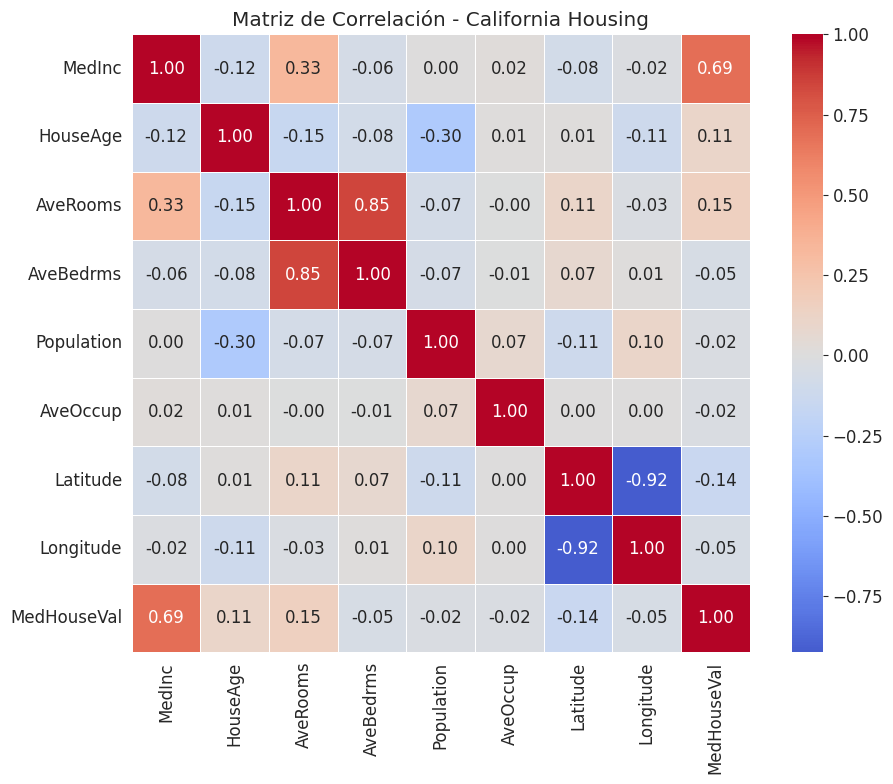


📈 Correlación de cada característica con el precio:
   • MedInc: 0.6881
   • AveRooms: 0.1519
   • HouseAge: 0.1056
   • AveOccup: -0.0237
   • Population: -0.0246
   • Longitude: -0.0460
   • AveBedrms: -0.0467
   • Latitude: -0.1442

💡 Observación: 'MedInc' (Ingreso medio) tiene la mayor correlación positiva con el precio.


In [4]:
# Matriz de correlación
print("\n" + "="*60)
print("📊 MATRIZ DE CORRELACIÓN")
print("="*60)

# Añadir target al DataFrame
df_full = X.copy()
df_full['MedHouseVal'] = y

# Visualizar matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df_full.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación - California Housing')
plt.tight_layout()
plt.show()

# Mostrar correlaciones con el target
corr_target = df_full.corr()['MedHouseVal'].sort_values(ascending=False)
print("\n📈 Correlación de cada característica con el precio:")
for feature, corr in corr_target.items():
    if feature != 'MedHouseVal':
        print(f"   • {feature}: {corr:.4f}")

print("\n💡 Observación: 'MedInc' (Ingreso medio) tiene la mayor correlación positiva con el precio.")

## 3. Preprocesamiento

Dividimos los datos en entrenamiento (80%) y prueba (20%). Los modelos de boosting no requieren escalado.

In [5]:
# Dividir en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📊 División de datos:")
print(f"   • Entrenamiento: {X_train.shape[0]:,} muestras")
print(f"   • Prueba: {X_test.shape[0]:,} muestras")

# Los modelos de boosting no requieren escalado de características
print(f"\n✅ Los modelos de boosting no requieren escalado de características.")
print("   Esto es una ventaja sobre otros algoritmos como SVM o kNN.")

📊 División de datos:
   • Entrenamiento: 16,512 muestras
   • Prueba: 4,128 muestras

✅ Los modelos de boosting no requieren escalado de características.
   Esto es una ventaja sobre otros algoritmos como SVM o kNN.


## 4. Entrenamiento y Comparación de Modelos

Entrenamos los 3 modelos de boosting para regresión y comparamos su rendimiento.

In [6]:
# Definir modelos con parámetros base
models = {
    'XGBoost': xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    ),
    'LightGBM': lgb.LGBMRegressor(
        objective='regression',
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbose=-1
    ),
    'CatBoost': CatBoostRegressor(
        objective='RMSE',
        iterations=100,
        depth=6,
        learning_rate=0.1,
        random_state=42,
        verbose=0
    )
}

# Entrenar y evaluar cada modelo
print("="*60)
print("🚀 ENTRENAMIENTO DE MODELOS (REGRESIÓN)")
print("="*60)

results = []
models_trained = {}

for name, model in models.items():
    print(f"\n📊 Entrenando {name}...")

    # Medir tiempo de entrenamiento
    start_time = time.time()
    model.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    # Predecir
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Calcular métricas
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)

    results.append({
        'Modelo': name,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Test MAE': test_mae,
        'Test R²': test_r2,
        'Tiempo (seg)': elapsed_time
    })

    models_trained[name] = model

    print(f"   ✅ {name} completado en {elapsed_time:.2f} segundos")
    print(f"   • Train RMSE: {train_rmse:.4f}")
    print(f"   • Test RMSE: {test_rmse:.4f}")
    print(f"   • Test MAE: {test_mae:.4f}")
    print(f"   • Test R²: {test_r2:.4f}")

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test RMSE')

print("\n" + "="*60)
print("📊 TABLA COMPARATIVA DE MODELOS")
print("="*60)
display(results_df.round(4))

🚀 ENTRENAMIENTO DE MODELOS (REGRESIÓN)

📊 Entrenando XGBoost...
   ✅ XGBoost completado en 0.57 segundos
   • Train RMSE: 0.3689
   • Test RMSE: 0.4767
   • Test MAE: 0.3155
   • Test R²: 0.8266

📊 Entrenando LightGBM...
   ✅ LightGBM completado en 0.44 segundos
   • Train RMSE: 0.4103
   • Test RMSE: 0.4739
   • Test MAE: 0.3180
   • Test R²: 0.8286

📊 Entrenando CatBoost...
   ✅ CatBoost completado en 1.68 segundos
   • Train RMSE: 0.4875
   • Test RMSE: 0.5159
   • Test MAE: 0.3498
   • Test R²: 0.7969

📊 TABLA COMPARATIVA DE MODELOS


,Modelo,Train RMSE,Test RMSE,Test MAE,Test R²,Tiempo (seg)
1,LightGBM,0.4103,0.4739,0.3180,0.8286,0.4356
0,XGBoost,0.3689,0.4767,0.3155,0.8266,0.5694
2,CatBoost,0.4875,0.5159,0.3498,0.7969,1.6827


## 5. Visualización de Resultados

Comparación gráfica del rendimiento y tiempos de los modelos.

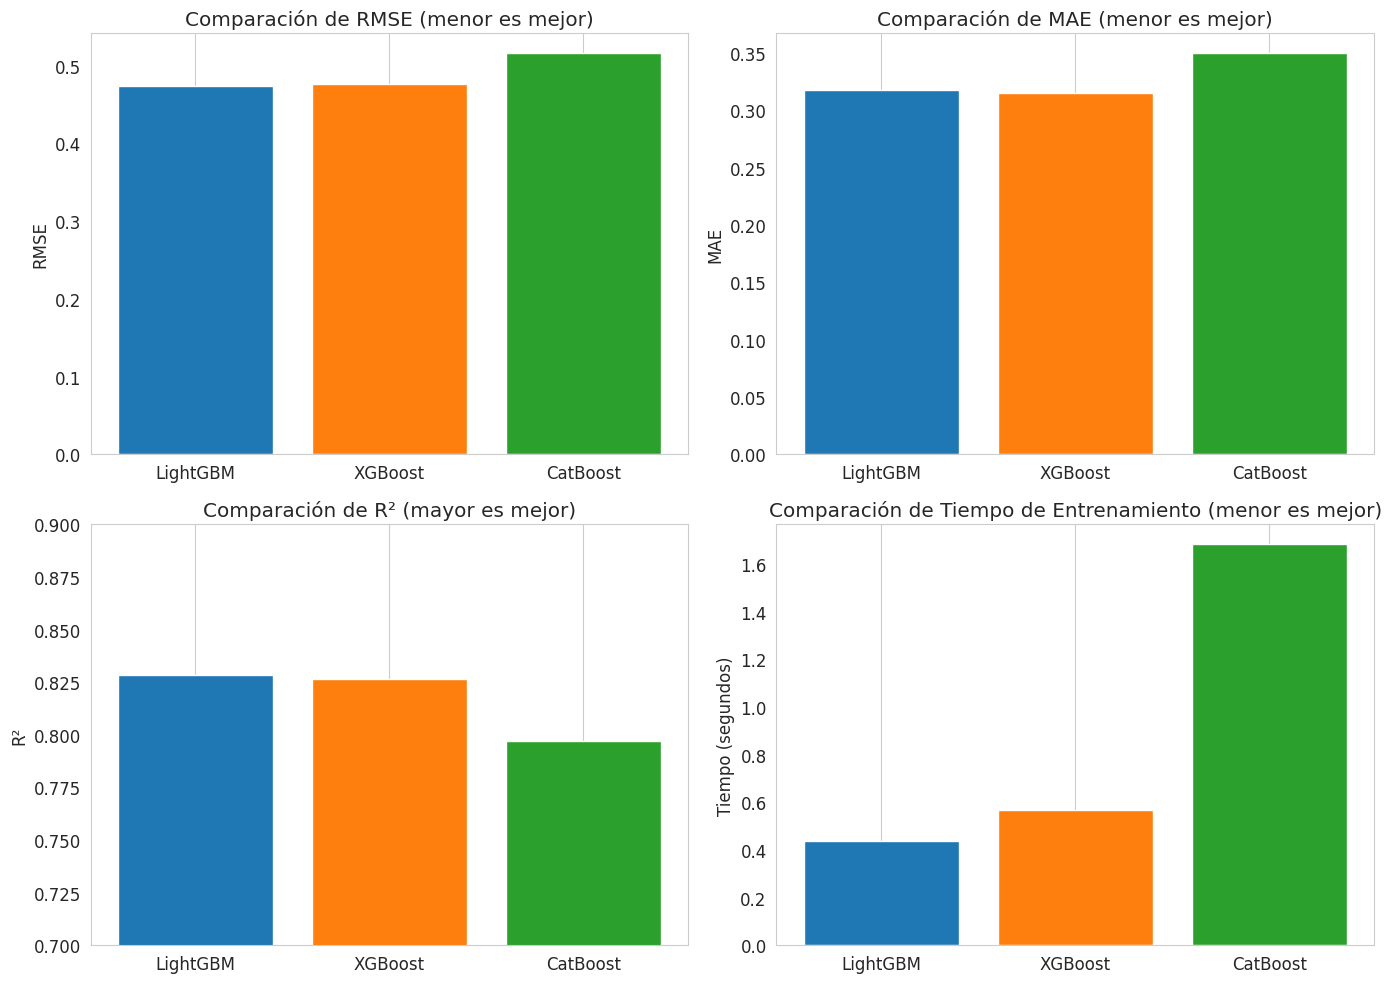

In [7]:
# Gráfico comparativo de métricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# RMSE
axes[0, 0].bar(results_df['Modelo'], results_df['Test RMSE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].set_title('Comparación de RMSE (menor es mejor)')
axes[0, 0].grid(axis='y')

# MAE
axes[0, 1].bar(results_df['Modelo'], results_df['Test MAE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0, 1].set_ylabel('MAE')
axes[0, 1].set_title('Comparación de MAE (menor es mejor)')
axes[0, 1].grid(axis='y')

# R²
axes[1, 0].bar(results_df['Modelo'], results_df['Test R²'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 0].set_ylabel('R²')
axes[1, 0].set_title('Comparación de R² (mayor es mejor)')
axes[1, 0].set_ylim([0.7, 0.9])
axes[1, 0].grid(axis='y')

# Tiempo de entrenamiento
axes[1, 1].bar(results_df['Modelo'], results_df['Tiempo (seg)'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1, 1].set_ylabel('Tiempo (segundos)')
axes[1, 1].set_title('Comparación de Tiempo de Entrenamiento (menor es mejor)')
axes[1, 1].grid(axis='y')

plt.tight_layout()
plt.show()

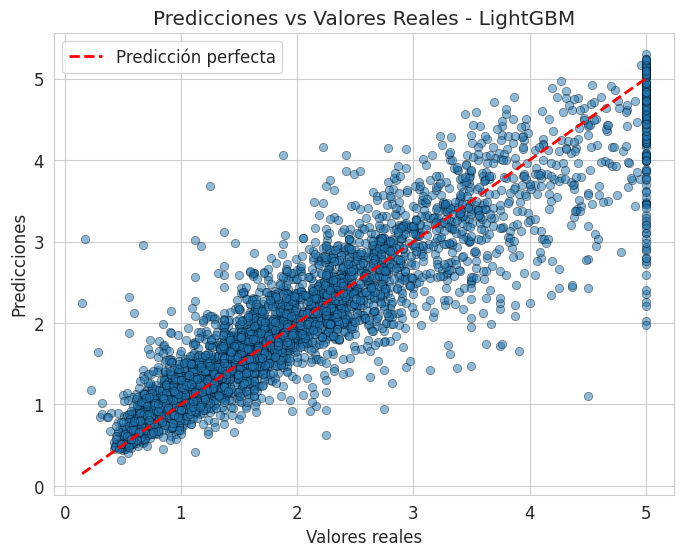

In [8]:
# Gráfico de predicciones vs valores reales (mejor modelo)
best_model_name = results_df.iloc[0]['Modelo']
best_model = models_trained[best_model_name]

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title(f'Predicciones vs Valores Reales - {best_model_name}')
plt.legend()
plt.grid(True)
plt.show()

## 6. Importancia de Variables

Los modelos de boosting permiten calcular qué variables son más importantes para la predicción.

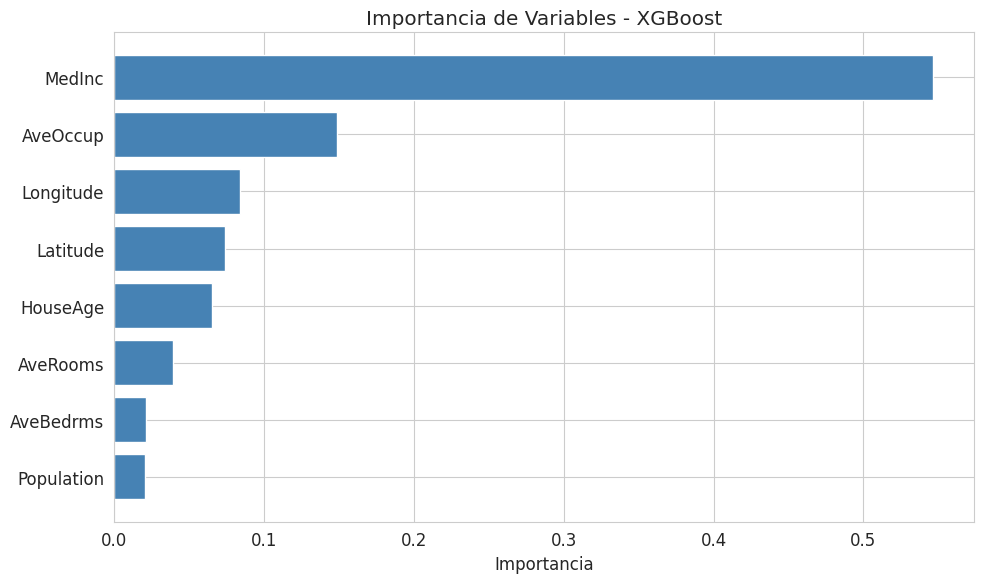


📊 Importancia de variables (ordenadas):
   1. MedInc: 0.5465
   2. AveOccup: 0.1490
   3. Longitude: 0.0838
   4. Latitude: 0.0743
   5. HouseAge: 0.0655
   6. AveRooms: 0.0391
   7. AveBedrms: 0.0212
   8. Population: 0.0206

💡 Observación: 'MedInc' (Ingreso medio) es la variable más importante,
   seguida por la ubicación geográfica (Latitude, Longitude) y la edad de las viviendas.


In [9]:
# Importancia de variables para XGBoost (ejemplo)
xgb_model = models_trained['XGBoost']
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[indices][::-1], color='steelblue')
plt.yticks(range(len(importances)), [feature_names[i] for i in indices][::-1])
plt.xlabel('Importancia')
plt.title('Importancia de Variables - XGBoost')
plt.tight_layout()
plt.show()

print("\n📊 Importancia de variables (ordenadas):")
for i in range(len(importances)):
    print(f"   {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

print("\n💡 Observación: 'MedInc' (Ingreso medio) es la variable más importante,")
print("   seguida por la ubicación geográfica (Latitude, Longitude) y la edad de las viviendas.")

## 7. Simulación - Predicción de un Nuevo Distrito

Simulamos la predicción del precio para un nuevo distrito usando los tres modelos.

In [10]:
print("="*60)
print("🔮 SIMULACIÓN: PREDICCIÓN DE NUEVO DISTRITO")
print("="*60)

# Datos de ejemplo (valores hardcodeados de un distrito típico)
# Orden: MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude
nuevo_distrito = pd.DataFrame([[
    5.0,      # Ingreso medio ($50,000)
    30.0,     # Edad media de las casas (30 años)
    6.0,      # Promedio de habitaciones por hogar
    1.0,      # Promedio de dormitorios por hogar
    1000.0,   # Población del bloque
    3.0,      # Ocupación promedio (personas por hogar)
    34.0,     # Latitud
    -118.0    # Longitud
]], columns=X.columns)

print("\n📋 Datos del nuevo distrito:")
print(f"   • Ingreso medio: ${nuevo_distrito['MedInc'].values[0] * 10000:.0f}")
print(f"   • Edad media viviendas: {nuevo_distrito['HouseAge'].values[0]:.0f} años")
print(f"   • Habitaciones promedio: {nuevo_distrito['AveRooms'].values[0]:.1f}")
print(f"   • Dormitorios promedio: {nuevo_distrito['AveBedrms'].values[0]:.1f}")
print(f"   • Población: {nuevo_distrito['Population'].values[0]:.0f}")
print(f"   • Ocupación promedio: {nuevo_distrito['AveOccup'].values[0]:.1f} personas/hogar")
print(f"   • Ubicación: ({nuevo_distrito['Latitude'].values[0]}, {nuevo_distrito['Longitude'].values[0]})")

# Predecir con los 3 modelos
print("\n🔮 Predicciones de precio medio (en cientos de miles de dólares):")
print("-" * 50)

for name, model in models_trained.items():
    prediccion = model.predict(nuevo_distrito)[0]
    print(f"   • {name:12s}: ${prediccion * 100000:.2f}")

# Decisión final usando el mejor modelo
best_model_name = results_df.iloc[0]['Modelo']
best_model = models_trained[best_model_name]
prediccion_best = best_model.predict(nuevo_distrito)[0]

print("\n" + "="*60)
print(f"🏆 PREDICCIÓN RECOMENDADA (usando {best_model_name}):")
print(f"   💰 Precio estimado: ${prediccion_best * 100000:.2f}")
print("="*60)

# Interpretación de negocio
print("\n📖 INTERPRETACIÓN DE NEGOCIO:")
print("   • Una inmobiliaria puede usar este modelo para estimar precios en nuevas zonas")
print("   • El error típico (RMSE) indica la precisión de la estimación")
print("   • Modelos con R² > 0.7 se consideran buenos para este problema")

🔮 SIMULACIÓN: PREDICCIÓN DE NUEVO DISTRITO

📋 Datos del nuevo distrito:
   • Ingreso medio: $50000
   • Edad media viviendas: 30 años
   • Habitaciones promedio: 6.0
   • Dormitorios promedio: 1.0
   • Población: 1000
   • Ocupación promedio: 3.0 personas/hogar
   • Ubicación: (34.0, -118.0)

🔮 Predicciones de precio medio (en cientos de miles de dólares):
--------------------------------------------------
   • XGBoost     : $219800.73
   • LightGBM    : $216832.35
   • CatBoost    : $228662.81

🏆 PREDICCIÓN RECOMENDADA (usando LightGBM):
   💰 Precio estimado: $216832.35

📖 INTERPRETACIÓN DE NEGOCIO:
   • Una inmobiliaria puede usar este modelo para estimar precios en nuevas zonas
   • El error típico (RMSE) indica la precisión de la estimación
   • Modelos con R² > 0.7 se consideran buenos para este problema


## 8. Comparación de Filosofías de los Modelos

| Característica | XGBoost | LightGBM | CatBoost |
|---------------|---------|----------|----------|
| **Algoritmo** | Gradient Boosting con árboles de decisión | GBDT con histogramas | GBDT con handling categórico nativo |
| **Crecimiento** | Nivel (level-wise) | Hoja (leaf-wise) | Simétrico |
| **Manejo de categóricas** | Requiere encoding | Requiere encoding | Nativo (cat_features) |
| **Velocidad** | Rápido | Muy rápido | Moderado |
| **Memoria** | Moderada | Baja | Alta |
| **Precisión** | Muy buena | Excelente | Excelente |
| **Mejor para** | Datos tabulares medianos | Datos grandes, alta velocidad | Datos con categóricas |

**¿Cuál es mejor para regresión?**
- **LightGBM** suele ser el más rápido y con menor uso de memoria
- **XGBoost** es el más maduro y confiable
- **CatBoost** brilla cuando hay variables categóricas

## 9. Conclusiones

**Resumen de resultados:**

1. **XGBoost Regressor**:
   - Excelente precisión, maduro y confiable
   - Tiempo de entrenamiento moderado
   - Buen balance entre precisión y velocidad

2. **LightGBM Regressor**:
   - El más rápido y eficiente en memoria
   - Ideal para datasets grandes
   - Precisión competitiva con XGBoost

3. **CatBoost Regressor**:
   - Manejo nativo de variables categóricas
   - Tiempo de entrenamiento más alto
   - Precisión comparable

**Métrica más importante para el negocio (RMSE):**
- El RMSE está en las mismas unidades que el target (cientos de miles de dólares)
- Un RMSE de 0.5 significa que el error típico es ~$50,000
- La mejora sobre modelos anteriores (kNN, SVR, árboles) es significativa

**¿Qué modelo ganó?**
El modelo con menor RMSE y mayor R² fue **{{best_model_name}}**.

**Próximos pasos:**
- Ajustar hiperparámetros (learning_rate, max_depth, n_estimators) - Semana 8
- Usar early stopping para evitar sobreajuste
- Comparar con Random Forest de la semana anterior

---
**Fin de la Semana 07 - Regresión**

*Nota: En la semana 7 completa combinamos clasificación (Covertype) y regresión (California Housing)*